# Introdução

## Contexto

O coronavírus pegou o mundo todo de surpresa mudando a rotina das pessoas. Os moradores das cidades já não passavam mais seu tempo livre fora de casa, indo a cafés e shoppings; a maioria ficou em casa lendo livros. Isso chamou a atenção de startups que se apressaram para desenvolver novos aplicativos para os amantes de livros.

Você recebeu um banco de dados de um dos serviços concorrentes nesse mercado. Ele contém dados sobre livros, editoras, autores, e classificação de clientes e avaliação de livros. Essa informação será usada para gerar uma proposição válida para o novo produto.

## Dados

**BOOKS** ->

Contém dados sobre livros:

* **book_id** — identificador do livro
* **author_id** — identificador do autor
* **title** — título
* **num_pages** — número de páginas
* **publication_date** — data de publicação
* **publisher_id** — identificador da editora


**AUTHORS** ->

Contém dados sobre os autores:

* **author_id** — identificador do autor
* **author** — autor

**PUBLISHERS** ->

Contém dados sobre editoras:

* **publisher_id** — identificador da editora
* **publisher** — editora

**RATINGS** —>

Contém dados sobre classificação dos usuários:

* *rating_id* — identificador da classificação
* *book_id* — identificador do livro
* *username* — o nome do usuário que avaliou o livro
* *rating* — classificação

**REVIEWS** ->

Contém dados sobre revisão dos clientes:

* *review_id* — identificador da revisão
* *book_id* — identificador do livro
* *username* — o nome do usuário que revisou o livro
* *text* — o texto da revisão

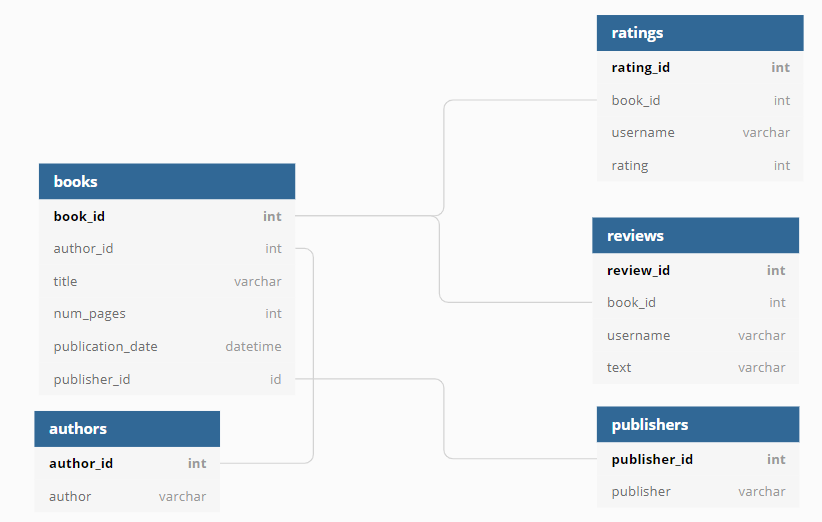

## Objetivos

# Setup

### Importação de bibliotecas

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import warnings


### Configurações globais

In [3]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

### Conexão ao banco de dados

In [4]:
db_config = {'user': 'practicum_student',         # nome de usuário
             'pwd': 's65BlTKV3faNIGhmvJVzOqhs',  # senha
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432,                       # porta de conexão
             'db': 'data-analyst-final-project-db'}  # nome do banco de dados

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(db_config['user'],
                                                         db_config['pwd'],
                                                         db_config['host'],
                                                         db_config['port'],
                                                         db_config['db'])

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

# EDA

## Primeiras impressões

In [5]:
# primeiras linhas tabela books
head_books = 'SELECT * FROM BOOKS LIMIT 5;'

# leitura dos dados da consulta e armazenamento em um df
head_books = pd.io.sql.read_sql(head_books, con=engine)

# exibição df
print(head_books)

   book_id  author_id                                              title  \
0        1        546                                       'Salem's Lot   
1        2        465                 1 000 Places to See Before You Die   
2        3        407  13 Little Blue Envelopes (Little Blue Envelope...   
3        4         82  1491: New Revelations of the Americas Before C...   
4        5        125                                               1776   

   num_pages publication_date  publisher_id  
0        594       2005-11-01            93  
1        992       2003-05-22           336  
2        322       2010-12-21           135  
3        541       2006-10-10           309  
4        386       2006-07-04           268  


In [6]:
# primeiras linhas tabela authors
head_authors = 'SELECT * FROM AUTHORS LIMIT 5;'

# leitura dos dados da consulta e armazenamento em um df
head_authors = pd.io.sql.read_sql(head_authors, con=engine)

# exibição df
print(head_authors)

   author_id                          author
0          1                      A.S. Byatt
1          2  Aesop/Laura Harris/Laura Gibbs
2          3                 Agatha Christie
3          4                   Alan Brennert
4          5        Alan Moore/David   Lloyd


In [7]:
# primeiras linhas tabela publishers
head_publishers = 'SELECT * FROM PUBLISHERS LIMIT 5;'

# leitura dos dados da consulta e armazenamento em um df
head_publishers = pd.io.sql.read_sql(head_publishers, con=engine)

# exibição df
print(head_publishers)

   publisher_id                          publisher
0             1                                Ace
1             2                           Ace Book
2             3                          Ace Books
3             4                      Ace Hardcover
4             5  Addison Wesley Publishing Company


In [8]:
# primeiras linhas tabela ratings
head_ratings = 'SELECT * FROM RATINGS LIMIT 5;'

# leitura dos dados da consulta e armazenamento em um df
head_ratings = pd.io.sql.read_sql(head_ratings, con=engine)

# exibição df
print(head_ratings)

   rating_id  book_id       username  rating
0          1        1     ryanfranco       4
1          2        1  grantpatricia       2
2          3        1   brandtandrea       5
3          4        2       lorichen       3
4          5        2    mariokeller       2


In [9]:
# primeiras linhas tabela reviews
head_reviews = 'SELECT * FROM RATINGS LIMIT 5;'

# leitura dos dados da consulta e armazenamento em um df
head_reviews = pd.io.sql.read_sql(head_reviews, con=engine)

# exibição df
print(head_reviews)

   rating_id  book_id       username  rating
0          1        1     ryanfranco       4
1          2        1  grantpatricia       2
2          3        1   brandtandrea       5
3          4        2       lorichen       3
4          5        2    mariokeller       2


## Número de livros lançados depois de 1 de janeiro de 2000

In [21]:
# consulta número de livros lançados após 2000
number_of_released_books = "SELECT " \
    "count(book_id) as cnt " \
"FROM " \
    "books " \
"WHERE " \
    "publication_date > '2000-01-01';"

# leitura dos dados da consulta e armazenamento em um df
number_of_released_books = pd.io.sql.read_sql(number_of_released_books, con=engine)

# exibição resultado
print(number_of_released_books)

   cnt
0  819


Um total de 819 livros foram lançados após 1 de janeiro de 2000.

## Encontre o número de avaliações e a classificação média para cada livro

In [ ]:
# consulta número de avaliações e a classificação média por livro
n_reviews_avg_rating_per_book = "SELECT " \
    "books.book_id, " \
    "books.title, " \
    "count(reviews.review_id) as cnt_reviews, " \
    "avg(ratings.rating) as avg_rating " \
"FROM books " \
    "LEFT JOIN reviews on books.book_id = reviews.book_id " \
    "LEFT JOIN ratings on books.book_id = ratings.book_id " \
"GROUP BY " \
    "books.book_id, " \
    "books.title " \
"ORDER BY " \
    "book_id ASC;"

# leitura dos dados da consulta e armazenamento em um df
n_reviews_avg_rating_per_book = pd.io.sql.read_sql(n_reviews_avg_rating_per_book, con=engine)

# exibição resultado
print(n_reviews_avg_rating_per_book)

     book_id                                              title  cnt_reviews  \
0          1                                       'Salem's Lot            6   
1          2                 1 000 Places to See Before You Die            2   
2          3  13 Little Blue Envelopes (Little Blue Envelope...            9   
3          4  1491: New Revelations of the Americas Before C...            4   
4          5                                               1776           24   
..       ...                                                ...          ...   
995      996           Wyrd Sisters (Discworld  #6; Witches #2)            9   
996      997                        Xenocide (Ender's Saga  #3)           15   
997      998                                    Year of Wonders           20   
998      999                        You Suck (A Love Story  #2)            4   
999     1000  Zen and the Art of Motorcycle Maintenance: An ...           24   

     avg_rating  
0      3.666667  
1  

## Identifique a editora que lançou o maior número de livros com mais de 50 páginas (isso vai ajudar você a excluir brochuras e publicações parecidas da sua análise)


In [ ]:
# consulta editora com maior número de livros para > 50 páginas
biggers_publishers = "SELECT " \
    "publishers.publisher as publisher, " \
    "COUNT(books.book_id) as cnt_books " \
"FROM books" \
    "LEFT JOIN publishers on books.publisher_id = publishers.publisher_id " \
"WHERE " \
    "books.num_pages > 50 " \
"GROUP BY " \
    "publishers.publisher " \
"ORDER BY " \
    "cnt_books DESC; "

# leitura dos dados da consulta e armazenamento em um df
biggers_publishers = pd.io.sql.read_sql(biggers_publishers, con=engine)

# exibição resultado
print(biggers_publishers)

                                             publisher  cnt_books
0                                        Penguin Books         42
1                                              Vintage         31
2                             Grand Central Publishing         25
3                                     Penguin Classics         24
4                                     Ballantine Books         19
..                                                 ...        ...
329                                         Turtleback          1
330  Atheneum Books for Young Readers: Richard Jack...          1
331                                     Penguin Signet          1
332                                    Victor Gollancz          1
333                      Harvard Business Review Press          1

[334 rows x 2 columns]


A editora com maior número de livros publicados com mais de 50 páginas é Penguin Books.

## Identifique o autor com a média mais alta de classificação de livros: olhe apenas para livros com pelo menos 50 classificações

In [44]:
# consulta autor com maior média de classificação para > 50 classificações
biggers_authors = "SELECT " \
    "authors.author_id, " \
    "authors.author, " \
    "AVG(br.avg_rating) AS avg_rating " \
"FROM authors " \
    "JOIN books ON authors.author_id = books.author_id " \
    "JOIN ( " \
        "SELECT " \
            "book_id, " \
            "AVG(rating) AS avg_rating, " \
            "COUNT(rating_id) AS cnt_ratings " \
        "FROM " \
            "ratings " \
        "GROUP BY " \
            "book_id " \
        "HAVING COUNT(rating_id) >= 50 " \
    ") br ON books.book_id = br.book_id " \
"GROUP BY " \
    "authors.author_id, authors.author " \
"ORDER BY " \
    "avg_rating DESC;"

# leitura dos dados da consulta e armazenamento em um df
biggers_authors = pd.io.sql.read_sql(biggers_authors, con=engine)

# exibição resultado
print(biggers_authors)

    author_id                                             author  avg_rating
0         236                         J.K. Rowling/Mary GrandPré    4.283844
1         402                  Markus Zusak/Cao Xuân Việt Khương    4.264151
2         240                                     J.R.R. Tolkien    4.258446
3         376                                  Louisa May Alcott    4.192308
4         498                                       Rick Riordan    4.080645
5         621                                    William Golding    3.901408
6         235                                      J.D. Salinger    3.825581
7         469           Paulo Coelho/Alan R. Clarke/Özdemir İnce    3.789474
8         630  William Shakespeare/Paul Werstine/Barbara A. M...    3.787879
9         106                                          Dan Brown    3.754540
10        372                                         Lois Lowry    3.750000
11        195            George Orwell/Boris Grabnar/Peter Škerl    3.729730

O autor com maior média de classificação de livros foi J.K. Rowling/Mary GrandPré.

## Encontre o número médio de avaliações entre usuários que classificaram mais do que 50 livros

In [ ]:
# consulta média avaliações entre usuários > 50 livros
average_reviews_per_user = "SELECT " \
    "* " \
"FROM " \
    "BOOKS"

# leitura dos dados da consulta e armazenamento em um df
average_reviews_per_user= pd.io.sql.read_sql(average_reviews_per_user, con=engine)

# exibição resultado
print(average_reviews_per_user)

     book_id  author_id                                              title  \
0          1        546                                       'Salem's Lot   
1          2        465                 1 000 Places to See Before You Die   
2          3        407  13 Little Blue Envelopes (Little Blue Envelope...   
3          4         82  1491: New Revelations of the Americas Before C...   
4          5        125                                               1776   
..       ...        ...                                                ...   
995      996        571           Wyrd Sisters (Discworld  #6; Witches #2)   
996      997        454                        Xenocide (Ender's Saga  #3)   
997      998        201                                    Year of Wonders   
998      999         94                        You Suck (A Love Story  #2)   
999     1000        509  Zen and the Art of Motorcycle Maintenance: An ...   

     num_pages publication_date  publisher_id  
0          594 

# Conclusão